**Вычисление скорости роста первых моментов**



In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate


In [15]:
def A11(Lambda, a):
    term = -Lambda**2 * np.log(1 - a / Lambda**2) / a
    assert abs(term) < 1e10
    return term

def A12(Lambda, a):
    term1 = - Lambda / a**0.5 * np.log((Lambda - a**0.5) / (Lambda + a**0.5))
    term2 = -Lambda**2 * np.log(1 - a / Lambda**2) / a
    assert abs(term1) < 1e10
    assert abs(term2) < 1e10
    
    return term1 + term2


def A21(Lambda, a):
    term1 = 2 * Lambda**2 / (Lambda**2 - a) 
    term2 = 2 * Lambda**2 / a * np.log(1 - a/Lambda**2)
    term = term1 + term2
    assert abs(term1) < 1e10
    assert abs(term2) < 1e10
    return term1

def B11(Lambda, a):
    return (2 * Lambda * (Lambda - Lambda * np.cosh(np.sqrt(a) / Lambda) +
                          np.sqrt(a) * np.sinh(np.sqrt(a) / Lambda))) / a

def B12(Lambda, a):
    return (2 * Lambda**2 * (-1 + np.cosh(np.sqrt(a) / Lambda))) / a

def B21(Lambda, a):
    return (2 * ((a + 2 * Lambda**2) * np.cosh(np.sqrt(a) / Lambda) - 2 *
                 Lambda * (Lambda + np.sqrt(a) * np.sinh(np.sqrt(a) / Lambda)))) / a

def CountMaxEigenValue2x2(Lambda, a, a11, a12, a21, lambda_prior=True):
    answer = []
    if (lambda_prior):
        for lambda_single in Lambda:
            answer.append(np.linalg.norm([[a11(lambda_single, a * lambda_single**2), a12(lambda_single, a* lambda_single**2)],
                                        [a21(lambda_single, a* lambda_single**2), a11(lambda_single, a* lambda_single**2)]]))
    else:
        for a_single in a:
            answer.append(np.linalg.norm([[a11(Lambda, a_single * Lambda**2), a12(Lambda, a_single* Lambda**2)],
                                        [a21(Lambda, a_single* Lambda**2), a11(Lambda, a_single* Lambda**2)]]))
    return answer

def CountMaxEigenValueForExponentialDistributionStep(Lambda, a, lambda_prior=True):
    return CountMaxEigenValue2x2(Lambda, a, A11, A12, A21, lambda_prior)

def CountMaxEigenValueForConstStep(Lambda, a, lambda_prior=True):
    return CountMaxEigenValue2x2(Lambda, a, B11, B12, B21, lambda_prior)

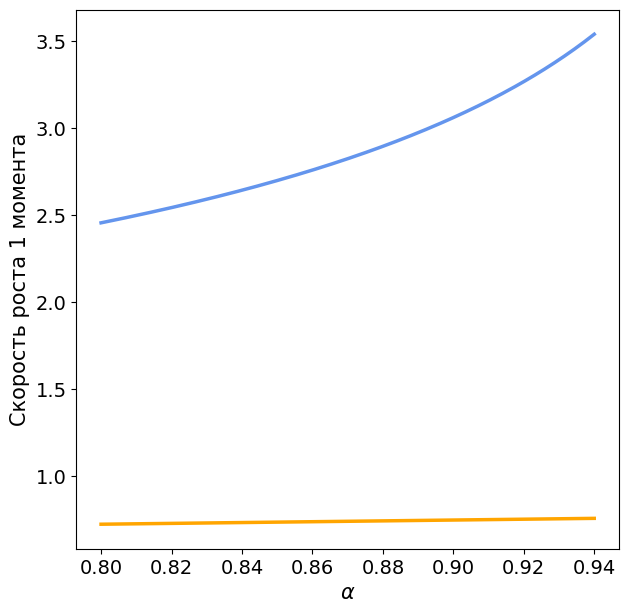

In [10]:
lambda_single_value = [ 1, 1/0.7, 1/0.1]
a_values = np.linspace(0.8, 0.94, 200)

l = lambda_single_value[0]
plt.figure(figsize=(7,7))

plt.plot(a_values,
                np.array(CountMaxEigenValueForExponentialDistributionStep(l, a_values, False)),
            linewidth=2.5,
            color='cornflowerblue',)
            # label=r'Экспоненциальный шаг со средним $\frac{1}{\lambda}$')
plt.plot(a_values,
                np.array(CountMaxEigenValueForConstStep(l, a_values, False)),
            linewidth=2.5,
         color='orange',)
                # label=r'Экспоненциальный шаг со средним $\frac{1}{\lambda}$')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel(f"$\\alpha$", fontsize=15)
plt.ylabel("Скорость роста 1 момента",fontsize=15)


# Показываем графики
# plt.savefig(f'./figures/fig 1 a rus.pdf')
plt.show()


**Вычисление скорости роста вторых моментов**

In [4]:
from scipy.special import expi
import math

from scipy.special import shichi
from scipy.special import erf
from scipy.integrate import quad

EulerGamma = 0.57721566490153

In [13]:
def cosh_integral(x):
    return shichi(x)[1]

# G - экспоненциальный шаг
# H - постоянный шаг

def G11(lmbda, a):
    res =  1/8 * (4 + (lmbda**2 * (- np.log(1 - 4 * a / lmbda**2))) / a)
    assert res is not None
    assert np.abs(res) < np.inf
    return res

def G12(lmbda, a):
    # assert(-2 * np.sqrt(a) + lmbda > 0)
    res = lmbda / (4 * a) * (lmbda * np.log(1 - 4 * a / lmbda**2) + 2 * a**0.5 *np.log((lmbda + 2 * a**0.5)/(lmbda - 2 * a**0.5)))
    assert res is not None
    assert np.abs(res) < np.inf
    return res

def G14(lmbda, a):
    ff = lambda xi, x: (np.exp(-x * lmbda) * lmbda * np.sinh(x * np.sqrt(xi))**2) / (a * x**2 * xi)
    return integrate.dblquad(ff, 0, 100, 0, a)[0]
    
def G21(lmbda, a):
    res =  lmbda * (-4*a*lmbda + (-4*a + lmbda**2) * (lmbda * (2*np.log(lmbda) - np.log(-2*np.sqrt(a)+lmbda)) + 2 * np.sqrt(a) *np.log(2*np.sqrt(a) + lmbda)) + (2*np.sqrt(a) - lmbda) * (2*np.sqrt(a)+lmbda)**2 * np.log(2*np.sqrt(a)+lmbda))/(8*a*(4*a - lmbda**2))
    assert res is not None
    assert np.abs(res) < np.inf
    return res

def G41(lmbda, a):
    res =  (4*a*(-32*a**3 + 16*a**2*lmbda**2 + 18*a*lmbda**4 - 3*lmbda**6) + 3*lmbda**4*(-4*a + lmbda**2)**2*(2*np.log(lmbda) - np.log(-2*np.sqrt(a) + lmbda) - np.log(2*np.sqrt(a) + lmbda)))/(16*a*(-4*a*lmbda + lmbda**3)**2)
    assert res is not None
    assert np.abs(res) < np.inf
    return res


def G23(lmbda, a):
    return G11(lmbda, a) - 1



def H11(lmbda, a):
    return (2 * a + lmbda**2 - lmbda**2 * np.cosh((2 * np.sqrt(a)) / lmbda) +
            2 * np.sqrt(a) * lmbda * np.sinh((2 * np.sqrt(a)) / lmbda)) / (4 * a)

def H12(lmbda, a):
    return (lmbda**2 * np.sinh(np.sqrt(a) / np.abs(lmbda))**2) / a

def H14(lmbda, a):
    return -((lmbda**2 * (-2 * cosh_integral((2 * np.sqrt(a)) / lmbda) +
                np.log(a) + 2 * (EulerGamma + np.log(2 / lmbda)))) / (2 * a))

def H21(lmbda, a):
    return ((2 * a + lmbda**2) * np.cosh((2 * np.sqrt(a)) / lmbda) -
            lmbda * (lmbda + 2 * np.sqrt(a) * np.sinh((2 * np.sqrt(a)) / lmbda))) / (4 * a)

def H41(lmbda, a):
    return (-2 * a**2 + 3 * lmbda**4 - 3 * lmbda**2 * (2 * a + lmbda**2) * np.cosh((2 * np.sqrt(a)) / lmbda) +
            2 * np.sqrt(a) * lmbda * (2 * a + 3 * lmbda**2) * np.sinh((2 * np.sqrt(a)) / lmbda)) / (8 * a * lmbda**2)

def H23(lmbda, a):
    assert( H11(lmbda, a) - 1 >= 0)
    return H11(lmbda, a) - 1


def CountMaxEigenValue4x4(Lambda, a, a11, a12, a21, a23, a14, a41, lambda_prior=True):
    answer = []

    if (lambda_prior):
        for lambda_single in Lambda:
            answer.append(np.linalg.norm([
                [a11(lambda_single, a * lambda_single**2 / 4), a12(lambda_single, a * lambda_single**2 / 4), a12(lambda_single, a * lambda_single**2 / 4), a14(lambda_single, a * lambda_single**2 / 4)],
                [a21(lambda_single, a * lambda_single**2 / 4), a11(lambda_single, a * lambda_single**2 / 4), a23(lambda_single, a * lambda_single**2 / 4), a12(lambda_single, a * lambda_single**2 / 4)],
                [a21(lambda_single, a * lambda_single**2 / 4), a23(lambda_single, a * lambda_single**2 / 4), a11(lambda_single, a * lambda_single**2 / 4), a12(lambda_single, a * lambda_single**2 / 4)],
                [a41(lambda_single, a * lambda_single**2 / 4), a21(lambda_single, a * lambda_single**2 / 4), a21(lambda_single, a * lambda_single**2 / 4), a11(lambda_single, a * lambda_single**2 / 4)]]))
    else:
        for a_single in a:
            answer.append(np.linalg.norm([
                [a11(Lambda, a_single* Lambda**2 / 4), a12(Lambda, a_single* Lambda**2 / 4), a12(Lambda, a_single* Lambda**2 / 4), a14(Lambda, a_single* Lambda**2 / 4)],
                [a21(Lambda, a_single* Lambda**2 / 4), a11(Lambda, a_single* Lambda**2 / 4), a23(Lambda, a_single* Lambda**2 / 4), a12(Lambda, a_single* Lambda**2 / 4)],
                [a21(Lambda, a_single* Lambda**2 / 4), a23(Lambda, a_single* Lambda**2 / 4), a11(Lambda, a_single* Lambda**2 / 4), a12(Lambda, a_single* Lambda**2 / 4)],
                [a41(Lambda, a_single* Lambda**2 / 4), a21(Lambda, a_single* Lambda**2 / 4), a21(Lambda, a_single* Lambda**2 / 4), a11(Lambda, a_single* Lambda**2 / 4)]]))
    return answer

def CountMaxEigenValueForExponentialDistributionStep4x4(Lambda, a, lambda_prior=True):
    return CountMaxEigenValue4x4(Lambda, a, G11, G12, G21, G23, G14, G41, lambda_prior)

def CountMaxEigenValueForConstStep4x4(Lambda, a, lambda_prior=True):
    return CountMaxEigenValue4x4(Lambda, a, H11, H12, H21, H23, H14, H41, lambda_prior)

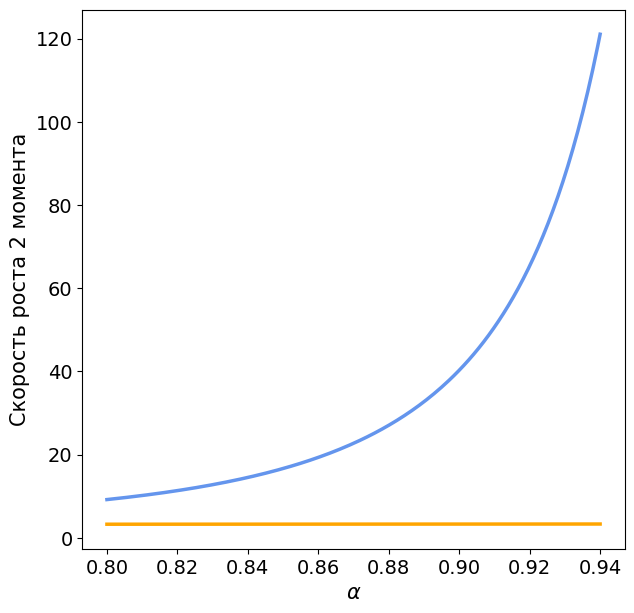

In [14]:
lambda_single_value = [ 1, 1/2., 1/3.]
a_values = np.linspace(0.8, 0.94, 200)

l = 1
plt.figure(figsize=(7,7))

plt.plot(a_values,
                np.array(CountMaxEigenValueForExponentialDistributionStep4x4(l, a_values, False)),
            linewidth=2.5,
            color='cornflowerblue',)
            # label=r'Экспоненциальный шаг со средним $\frac{1}{\lambda}$')
plt.plot(a_values,
                np.array(CountMaxEigenValueForConstStep4x4(l, a_values, False)),
            linewidth=2.5,
         color='orange',)
                # label=r'Экспоненциальный шаг со средним $\frac{1}{\lambda}$')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel(f"$\\alpha$", fontsize=15)
plt.ylabel("Скорость роста 2 момента",fontsize=15)


# Показываем графики
# plt.savefig(f'./figures/fig 2 a rus.pdf')
plt.show()
